In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import os
from collections import Counter
import yaml

plt.style.use("default")
sns.set_palette("husl")

print("🔬 MIT-BIH Data Exploration")
print("=" * 40)

🔬 MIT-BIH Data Exploration


In [5]:
def get_available_records():
    data_dir = "../data/raw/mit-bih/records"
    hea_files = [
        f.replace(".hea", "")
        for f in os.listdir(data_dir)
        if f.endswith(".hea") and f.split(".")[0].isdigit()
    ]
    return sorted(hea_files)

records = get_available_records()
print(f"📂 Available Records: {len(records)}")
print(f"Record IDs: {records[:10]}...")

📂 Available Records: 48
Record IDs: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109']...


In [6]:
def load_single_record(record_id):
    base = f"../data/raw/mit-bih/records/{record_id}"
    record = wfdb.rdrecord(base)
    annotation = wfdb.rdann(base, "atr")
    return record, annotation

record_100, ann_100 = load_single_record("100")

print("🔍 Examining Record 100:")
print("  Signal shape:", record_100.p_signal.shape)
print("  Sampling frequency:", record_100.fs, "Hz")
print("  Duration:", record_100.sig_len / record_100.fs / 60, "minutes")
print("  Lead names:", record_100.sig_name)
print("  Number of annotations:", len(ann_100.sample))

🔍 Examining Record 100:
  Signal shape: (650000, 2)
  Sampling frequency: 360 Hz
  Duration: 30.092592592592595 minutes
  Lead names: ['MLII', 'V5']
  Number of annotations: 2274


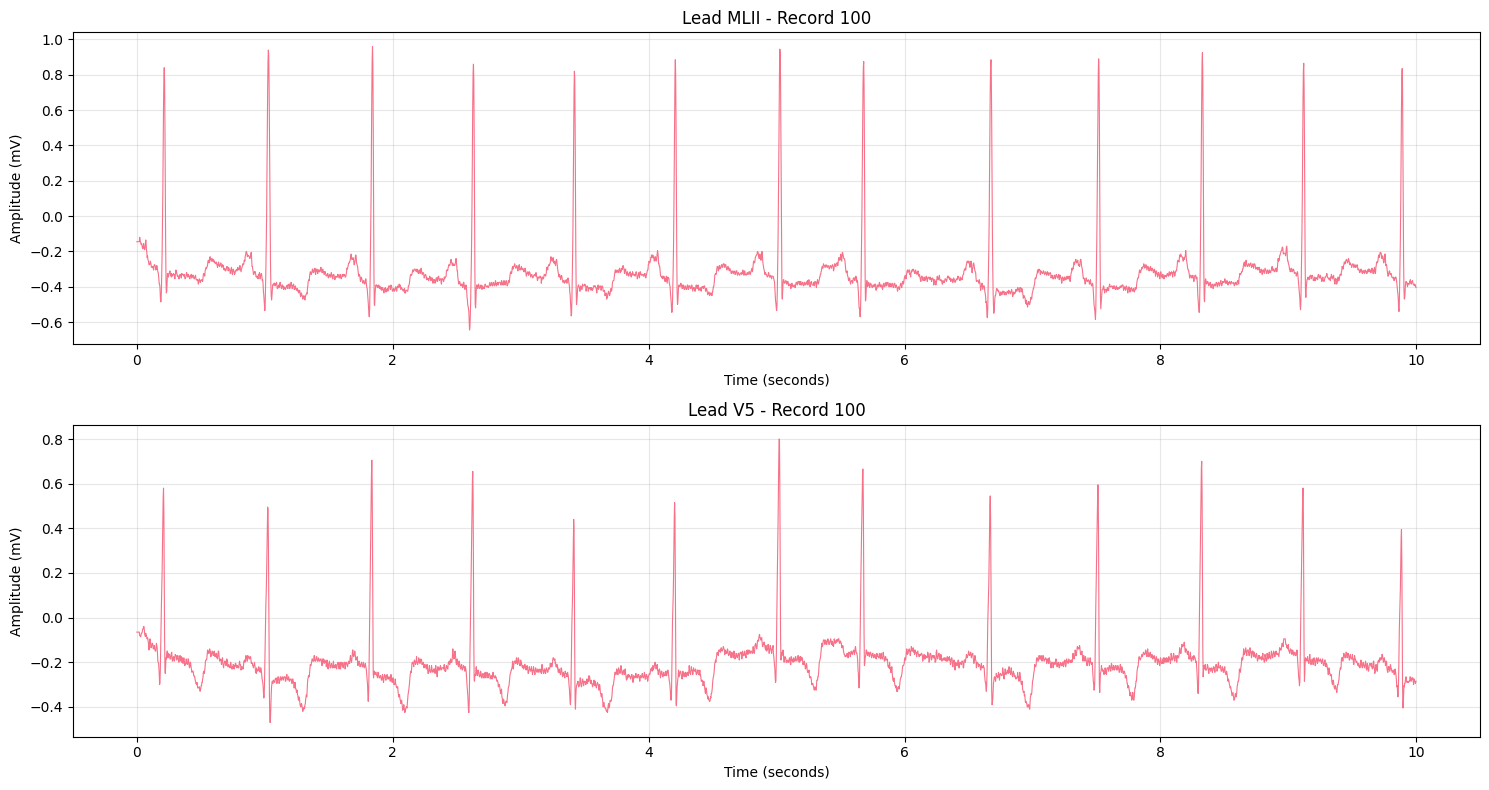

In [7]:
def plot_ecg_segment(record, start_time=0, duration=10):
    fs = record.fs
    start_sample = int(start_time * fs)
    end_sample = int((start_time + duration) * fs)
    time = np.arange(start_sample, end_sample) / fs

    fig, axes = plt.subplots(2, 1, figsize=(15, 8))
    for i, lead_name in enumerate(record.sig_name):
        axes[i].plot(time, record.p_signal[start_sample:end_sample, i], linewidth=0.8)
        axes[i].set_title(f"Lead {lead_name} - Record 100")
        axes[i].set_xlabel("Time (seconds)")
        axes[i].set_ylabel("Amplitude (mV)")
        axes[i].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_ecg_segment(record_100, 0, 10)

📋 Annotation Analysis for Record 100:


,Symbol,Count
0,N,2239
1,A,33
2,+,1
3,V,1


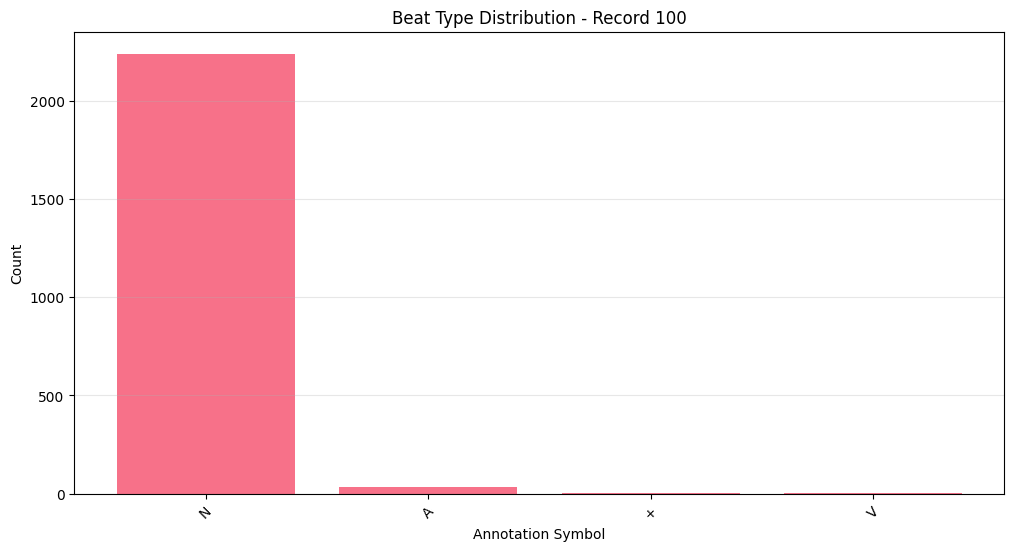

In [8]:
def analyze_annotations(annotation):
    symbol_counts = Counter(annotation.symbol)
    ann_df = pd.DataFrame(
        [{"Symbol": s, "Count": c} for s, c in symbol_counts.most_common()]
    )
    return ann_df, symbol_counts

ann_df_100, symbols_100 = analyze_annotations(ann_100)
print("📋 Annotation Analysis for Record 100:")
display(ann_df_100)

plt.figure(figsize=(12, 6))
plt.bar(ann_df_100["Symbol"], ann_df_100["Count"])
plt.title("Beat Type Distribution - Record 100")
plt.xlabel("Annotation Symbol")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()